In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [74]:
# Carregar os dados dos arquivos CSV para os semestres de 2024 e 2025 
# Concatenar os DataFrames dos semestres de 2024 e 2025

df_2024_1 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2024.01.csv', sep=';', decimal=',')
df_2024_2 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2024.02.csv', sep=';', decimal=',')
df_2025_1 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2025.01.csv', sep=';', decimal=',')
df_2025_2 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2025.02.csv', sep=';', decimal=',')


C:\Users\rodri\AppData\Local\Temp\ipykernel_9224\4125638147.py:6: DtypeWarning: Columns (0: Regiao - Sigla, 1: Estado - Sigla, 2: Municipio, 3: Revenda, 4: CNPJ da Revenda, 5: Nome da Rua, 6: Numero Rua, 7: Complemento, 8: Bairro, 9: Cep, 10: Produto, 11: Data da Coleta, 12: Unidade de Medida, 13: Bandeira) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2025_1 = pd.read_csv('Preços semestrais - AUTOMOTIVOS_2025.01.csv', sep=';', decimal=',')


In [75]:
# planilhas concatenadas

df = pd.concat([df_2024_1, df_2024_2,df_2025_1, df_2025_2],
ignore_index=True)
print(df.shape)
display(df.head())


(1712267, 16)


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,5.93,NaN,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,ETANOL,01/01/2024,3.99,NaN,R$ / litro,VIBRA
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,5.48,NaN,R$ / litro,VIBRA


In [76]:
df.columns

Index(['Regiao - Sigla', 'Estado - Sigla', 'Municipio', 'Revenda',
       'CNPJ da Revenda', 'Nome da Rua', 'Numero Rua', 'Complemento', 'Bairro',
       'Cep', 'Produto', 'Data da Coleta', 'Valor de Venda', 'Valor de Compra',
       'Unidade de Medida', 'Bandeira'],
      dtype='str')

01
Construção da base consolidada
O sistema da ANP exporta os dados por semestre. Antes de qualquer análise, consolide os quatro arquivos de 2024 e 2025 
em um único DataFrame. Confirme que a operação foi realizada corretamente verificando o número de linhas e as 
primeiras entradas do resultado.

(1712267, 16)


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,5.93,NaN,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,ETANOL,01/01/2024,3.99,NaN,R$ / litro,VIBRA
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,5.48,NaN,R$ / litro,VIBRA


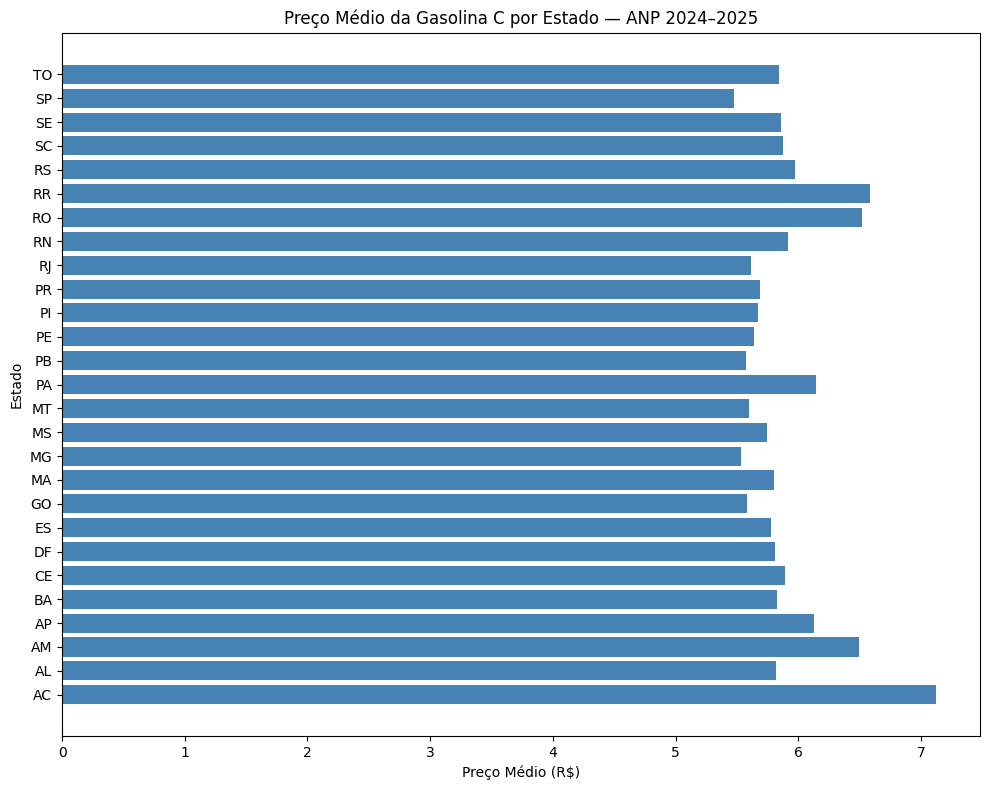

In [77]:
# Concatenação
df = pd.concat([df_2024_1, df_2024_2, df_2025_1, df_2025_2],
ignore_index=True)

# Verificação
print(df.shape)
display(df.head())

# Agrupamento (crie primeiro!)
df_estado = df.groupby('Estado - Sigla')['Valor de Venda'].mean()

# Gráfico
plt.figure(figsize=(10, 8))
plt.barh(df_estado.index, df_estado.values, color='steelblue')
plt.title('Preço Médio da Gasolina C por Estado — ANP 2024–2025')
plt.xlabel('Preço Médio (R$)')
plt.xticks(rotation=0)
plt.ylabel('Estado')
plt.tight_layout()
plt.show()


02
Gasolina C no Rio de Janeiro
O diretor quer entender como se comportaram os preços médios da Gasolina C no estado do Rio de Janeiro entre 2024 e 
2025. Calcule a média do Valor de Venda por município e apresente os resultados do maior para o menor. Quais municípios 
praticaram os maiores preços médios no período?

In [78]:
df_gas_rj = df.loc[(df['Estado - Sigla'] == 'RJ') & (df['Produto'] == 'GASOLINA')]

In [79]:
df_munic_rj_gas = df_gas_rj.groupby('Municipio')['Valor de Venda'].mean().reset_index()

In [80]:
df_munic_rj_gas = df_gas_rj.groupby('Municipio')['Valor de Venda'].mean().reset_index()
df_munic_rj_gas.sort_values(by='Valor de Venda', ascending=False, inplace=True)
df_munic_rj_gas


,Municipio,Valor de Venda
29,TRES RIOS,6.591634
0,ANGRA DOS REIS,6.521620
18,PETROPOLIS,6.479639
2,BARRA DO PIRAI,6.375640
11,MACAE,6.364828
16,NOVA FRIBURGO,6.357044
10,ITAPERUNA,6.352013
6,CAMPOS DOS GOYTACAZES,6.338306
5,CABO FRIO,6.322089
23,SAO FRANCISCO DE ITABAPOANA,6.214804


Municipio
ANGRA DOS REIS    6.379451
MACAE             6.133114
TRES RIOS         6.083138
PETROPOLIS        5.990904
BARRA DO PIRAI    5.966166
Name: Valor de Venda, dtype: float64


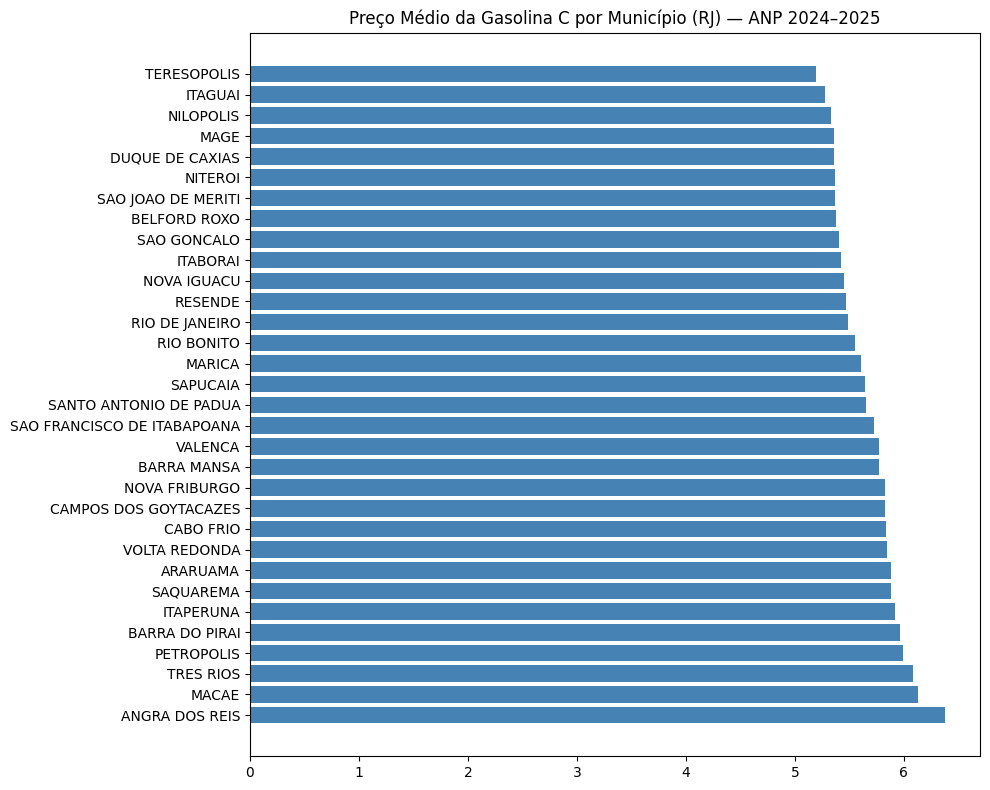

In [81]:
# Filtrar apenas o estado do Rio de Janeiro
df_gas_rj = df[df['Estado - Sigla'] == 'RJ']

# Calcular o preço médio da Gasolina C por município
media_municipio = df_gas_rj.groupby('Municipio')['Valor de Venda'].mean()

# Ordenar do maior para o menor preço médio
media_municipio = media_municipio.sort_values(ascending=False)

# Ver os primeiros municípios (os mais caros)
print(media_municipio.head())

# Gráfico
plt.figure(figsize=(10, 8))
plt.barh(media_municipio.index, media_municipio.values,
         color='#4682B4') #steelblue
plt.title('Preço Médio da Gasolina C por Município (RJ) — ANP 2024–2025')
#plt.xlabel('Preço Médio (R$)')
#plt.ylabel('Município')
plt.tight_layout()
plt.show()


03
Outliers de preço: Gasolina C no RJ

Ainda com foco na Gasolina C no Rio de Janeiro, identifique os postos com preços estatisticamente atípicos. Calcule o IQR e 
os limites para o Valor de Venda. Existem postos praticando preços fora do padrão? Apresente os grupos de outliers 
superiores e inferiores ordenados de forma adequada. Se o limite inferior for negativo, o que isso indica?

In [82]:
df_posto_rj = df_gas_rj.groupby('Revenda')['Valor de Venda'].mean().reset_index()
# Ordenar do maior para o menor preço médio
#df_posto_rj.sort_values(by='Valor de Venda', ascending=False, inplace=True)
df_posto_rj

,Revenda,Valor de Venda
0,3POSTO JULIO DE CASTILHO LIMITADA,6.200570
1,A C TRANCOZO M B COMBUSTIVEIS LTDA,6.239412
2,A C TRANCOZO M B COMBUSTÍVEIS LTDA,6.049250
3,A O LESSA LTDA,5.718131
4,A.P ITAIPU COMBUSTIVEIS LTDA,4.990000
...,...,...
883,VIVIANO AUTO POSTO COMERCIAL LTDA,5.450000
884,W M DO LOCAL COMERCIO E SERVICOS LTDA,4.390000
885,W. M. DO LOCAL COMERCIO E SERVICOS LTDA.,4.190000
886,WEST POINT CAR POSTO DE ABASTECIMENTO LTDA,5.285232


In [83]:
array_postos = df_posto_rj['Valor de Venda']

maximo = np.max(array_postos)
minimo = np.min(array_postos)
media = np.mean(array_postos)
mediana = np.median(array_postos)
q1 = np.percentile(array_postos, 25)
q2 = np.percentile(array_postos, 50)
q3 = np.percentile(array_postos, 75)
iqr = q3 - q1
distancia = (media - mediana) / mediana
amplitude = maximo - minimo
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)


print(f'O valor máximo é: {maximo}') # isto é um print formatado
print(f'O valor minimo é: {minimo}')
print(f'A Média é: {media}')
print(f'O Madiana é: {mediana}')
print(f'q1: {q1}')
print(f'q2: {q2}')
print(f'q3: {q3}')
#print(f'A Distância: {distancia:.2f}')
print(f'A Distância: {distancia:.2%}')
print(f"Amplitude: {amplitude:.2f}")
print(f'Limite Superior: ≈ R$ {limite_superior:.2f}')
print(f'Limite Inferior: ≈ R$ {limite_inferior:.2f}')


O valor máximo é: 6.99072463768116
O valor minimo é: 4.19
A Média é: 5.551552217068474
O Madiana é: 5.516791006642821
q1: 5.278851022395326
q2: 5.516791006642821
q3: 5.8324465811965815
A Distância: 0.63%
Amplitude: 2.80
Limite Superior: ≈ R$ 6.66
Limite Inferior: ≈ R$ 4.45


In [84]:
df_outliers_posto_rj = df_posto_rj.loc[(df_posto_rj['Valor de Venda'] > limite_superior)]  # | (df_posto_rj['Valor de Venda'] < limite_inferior)]
df_outliers_posto_rj


,Revenda,Valor de Venda
78,AUTO POSTO DE COMBUSTIVEIS M C 2000 DE SANTA I...,6.990725
109,AUTO POSTO ESAL LTDA.,6.663098
132,AUTO POSTO JAPUIBA LTDA,6.665000
442,POSTO BARRA MANSA LTDA,6.755870
701,POSTO JARDIM OCEANICO LTDA.,6.807042


q1: 5.39
q3: 6.29
IQR: 0.90
Limite Superior: 7.64
Limite Inferior: 4.04


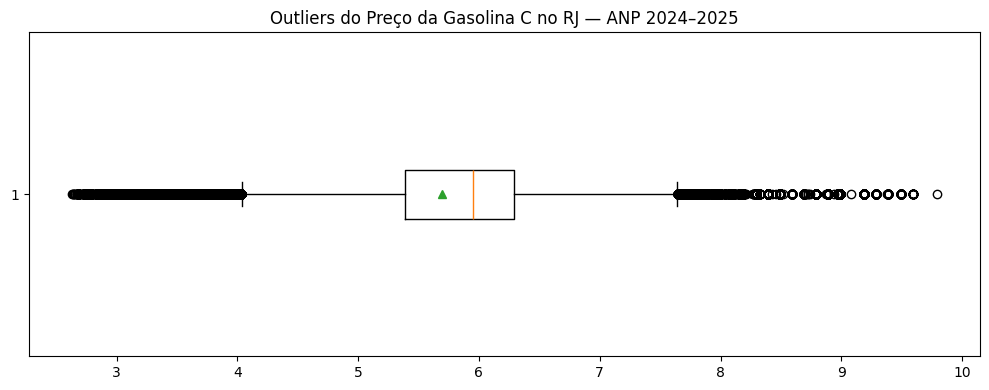

RESPOSTA COM IA:

q1: R$ 5.39
q3: R$ 6.29
IQR: 0.90
Limite Superior: R$ 7.64
Limite Inferior: R$ 4.04


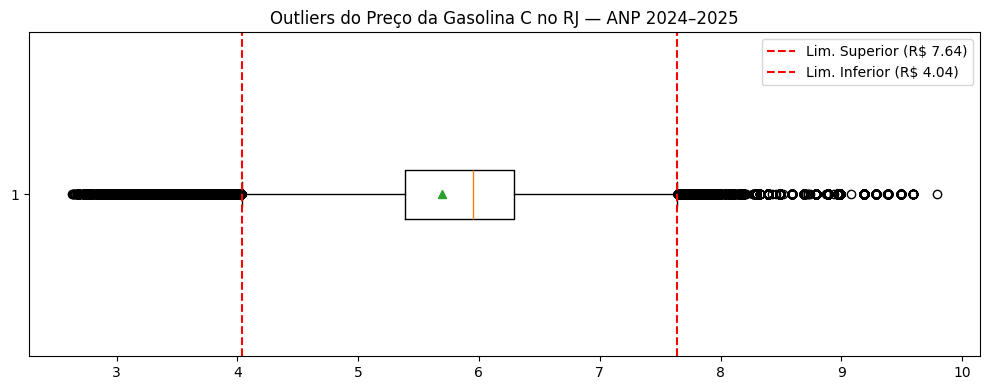

In [88]:
# Cálculo dos outliers usando o método do IQR
array_valor_outlier = np.array(df['Valor de Venda'].dropna())
q1 = np.percentile(array_valor_outlier, 25)
q3 = np.percentile(array_valor_outlier, 75)
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)
print(f'q1: {q1:.2f}')
print(f'q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Limite Superior: {limite_superior:.2f}')
print(f'Limite Inferior: {limite_inferior:.2f}')

# Gráfico
plt.figure(figsize=(10, 4))
plt.boxplot(df['Valor de Venda'].dropna(),vert=False, showmeans=True)
plt.title('Outliers do Preço da Gasolina C no RJ — ANP 2024–2025')
plt.tight_layout()
plt.show()

print('RESPOSTA COM IA:\n')

import matplotlib.pyplot as plt
import numpy as np

# Filtrar os preços de venda válidos (removendo NaN)
precos_validos = df['Valor de Venda'].dropna()

# Cálculo dos quartis e do IQR
q1 = np.percentile(precos_validos, 25)
q3 = np.percentile(precos_validos, 75)
iqr = q3 - q1

limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

# Imprimir os resultados
print(f'q1: R$ {q1:.2f}')
print(f'q3: R$ {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Limite Superior: R$ {limite_superior:.2f}')
print(f'Limite Inferior: R$ {limite_inferior:.2f}')

# Gráfico enriquecido
plt.figure(figsize=(10, 4))
plt.boxplot(precos_validos, vert=False, showmeans=True)

# Adicionar linhas verticais para os limites
plt.axvline(limite_superior, color='red', linestyle='--', label=f'Lim. Superior (R$ {limite_superior:.2f})')
plt.axvline(limite_inferior, color='red', linestyle='--', label=f'Lim. Inferior (R$ {limite_inferior:.2f})')
# Adicionar anotações para os quartis
plt.title('Outliers do Preço da Gasolina C no RJ — ANP 2024–2025')
plt.legend() # Mostra a legenda das linhas de limite
plt.tight_layout()
plt.show()


04
Comparando estados: Etanol Hidratado
O diretor quer comparar o preço médio do Etanol Hidratado entre RJ e SP em 2024 e 2025. Filtre os dados para os dois 
estados e calcule a média do Valor de Venda para cada um. Em seguida, aplique o critério de outliers em cada estado 
separadamente. Os limites e os casos atípicos são semelhantes ou diferentes entre os dois estados?

In [86]:
df_rj_sp_etanol = df.loc[(df['Estado - Sigla'].isin(['RJ', 'SP'])) & (df['Produto'] == 'Etanol')]

df_rj_sp_etanol = df_rj_sp_etanol.groupby(by='Valor de Venda').mean().reset_index()

df_rj_sp_etanol


TypeError: dtype 'str' does not support operation 'mean'

05
Bairros da capital: preços dentro ou fora do padrão?
A diretoria quer entender como os preços da Gasolina C se distribuem entre os diferentes bairros da cidade do Rio de 
Janeiro. Existem bairros com dados atípicos?
A partir desse recorte:
1
Calcule a média do Valor de Venda por bairro (coluna Bairro) e ordene do maior para o menor.
2 Aplique o IQR para identificar bairros com preços médios estatisticamente atípicos — tanto os superiores quanto os 
inferiores.
3 Os bairros outliers superiores são regiões nobres da cidade? Os inferiores são periferias ou regiões com alta 
concorrência? Apresente sua conclusão.


In [ ]:
df_munic_rj = df.loc[(df['Município'] == 'RIO DE JANEIRO') & (df['Produto'] == 'GASOLINA')]

df_munic_rj


KeyError: 'Município'

In [ ]:
df_bairro_rj = df.munic_rj.groupby('Bairro')['Valor de Venda'].mean().reset_index()

df_bairro_rj.sort_values(by='Valor de Venda', ascending=False, inplace=True)

df_bairro_rj

AttributeError: 'DataFrame' object has no attribute 'munic_rj'

Limite Superior: ≈ R$ 7.64
Limite Inferior: ≈ R$ 4.04


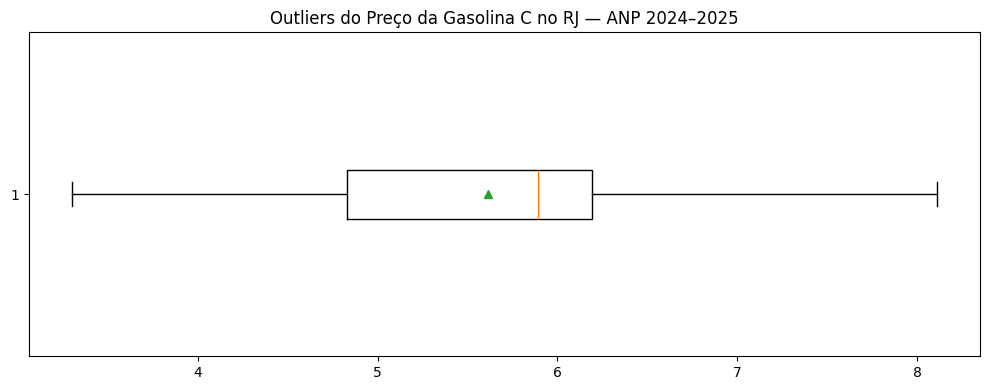

In [ ]:
#array_valor_outlier = np.array(df['Valor de Venda'])
array_valor_outlier = np.array(df['Valor de Venda'].dropna())
q1 = np.percentile(array_valor_outlier, 25)
q3 = np.percentile(array_valor_outlier, 75)
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)
#print(q1)
#print(q3)
print(f'Limite Superior: ≈ R$ {limite_superior:.2f}')
print(f'Limite Inferior: ≈ R$ {limite_inferior:.2f}')

# Gráfico
plt.figure(figsize=(10, 4))
#plt.boxplot(df_rj['Valor de Venda'].dropna(),vert=True)
plt.boxplot(df_rj['Valor de Venda'].dropna(),vert=False, showmeans=True)
plt.title('Outliers do Preço da Gasolina C no RJ — ANP 2024–2025')
plt.tight_layout()
plt.show()

Variância, Desvio Padrão,
Covariância e Correlação

In [ ]:
import numpy as np
import pandas as pd

#Variância
dados = {
'aluno': ['Ana','Bruno','Carol','Diego',
'Elisa','Felipe','Gabi','Hugo'],
'nota': [8.5, 6.0, 9.2, 5.5, 7.8, 4.0, 9.0, 6.5],
'horas': [6, 3, 8, 2, 5, 1, 7, 4 ]}
df = pd.DataFrame(dados)
# Variância das notas
variancia = np.var(df['nota'])
print(f"Variância: {variancia:.2f}")
# Saída: Variância: 3.02



Variância: 3.02


Desvio Padrão — A Mais Usada! 
É a raiz quadrada da variância
Prof. Cassio Ribeiro | Análise de Dados | SENAC RJ
Por que usar desvio padrão e não variância?
A variância eleva ao quadrado → a unidade fica "nota²", o que é difícil de interpretar.
O desvio padrão tira a raiz quadrada e volta à mesma unidade original: "nota".
Assim fica muito mais fácil dizer: "as notas variam em média ±1.74 pontos".


In [ ]:
# Desvio padrão das notas
desvio = np.std(df['nota'])
print(f"Desvio Padrão: {desvio:.2f}") # o ideal é array
# Saída: Desvio Padrão: 1.74
# Interpretando com a média
media = np.mean(df['nota'])
print(f"Média das notas: {media:.2f}")
print(f"Faixa típica: {media-desvio:.2f} até {media+desvio:.2f}")
# Saída:
# Média das notas: 7.06
# Faixa típica: 5.32 até 8.80



Desvio Padrão: 1.74
Média das notas: 7.06
Faixa típica: 5.32 até 8.80


Covariância no Python 
np.cov() — retorna uma matriz com os valores

In [ ]:
matriz_cov = np.cov(df['nota'], df['horas'])
print(matriz_cov)
# [[3.46 4.48]
# [4.48 6.00]]


[[3.45696429 4.47857143]
 [4.47857143 6.        ]]


In [ ]:
# Extraindo só o valor da covariância
cov_valor = matriz_cov[0, 1]
print(f"Covariância: {cov_valor:.2f}")
# Saída: Covariância: 4.48


Covariância: 4.48


In [ ]:
# Forma alternativa com Pandas
print(df[['nota','horas']].cov())
# nota horas
# nota 3.456 4.479
# horas 4.479 6.000


           nota     horas
nota   3.456964  4.478571
horas  4.478571  6.000000


Correlação — A Força da Relação

In [ ]:
# Forma 1 — Pandas (mais usada na prática)
corr_pandas = df[['nota','horas']].corr()
print(corr_pandas)
# nota horas
# nota 1.0000 0.9749
# horas 0.9749 1.0000


           nota     horas
nota   1.000000  0.983369
horas  0.983369  1.000000


In [ ]:
# Forma 2 — NumPy
r = np.corrcoef(df['nota'], df['horas'])
print(f"Pearson r = {r[0,1]:.4f}")
# Saída: Pearson r = 0.9749
# Interpretação:
# r = 0.97 → correlação MUITO FORTE positiva
# Confirma: mais horas de estudo = nota maior!

Pearson r = 0.9834


Código Completo — Tudo junto! 

In [ ]:
import numpy as np
import pandas as pd

dados = {
'aluno': ['Ana','Bruno','Carol','Diego',
'Elisa','Felipe','Gabi','Hugo'],
'nota': [8.5, 6.0, 9.2, 5.5, 7.8, 4.0, 9.0, 6.5],
'horas': [6, 3, 8, 2, 5, 1, 7, 4 ]}
df = pd.DataFrame(dados)

print(f"Variância: {np.var(df['nota']):.2f}")
print(f"Desvio Padrão: {np.std(df['nota']):.2f}")

cov = np.cov(df['nota'], df['horas'])[0, 1]
print(f"Covariância: {cov:.2f}")

r = np.corrcoef(df['nota'], df['horas'])[0, 1]
print(f"Pearson r: {r:.4f}")
print("Relação: MUITO FORTE POSITIVA!")

Variância: 3.02
Desvio Padrão: 1.74
Covariância: 4.48
Pearson r: 0.9834
Relação: MUITO FORTE POSITIVA!
